# Part 2, Tasks a and b: Perceptron from scratch

A perceptron written with numpy only: step activation, online perceptron rule, zero initial weights, training data shuffled every epoch.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

EPOCHS = [1, 5, 10, 15, 20, 50, 60, 80, 100, 120, 150, 200]


def load(name):
    """Load data/<name>.csv -> (X, y, feature names). The last column is the 0/1 class."""
    path = f"data/{name}.csv"
    names = open(path).readline().strip().split(",")[:-1]
    data = np.loadtxt(path, delimiter=",", skiprows=1)
    return data[:, :-1], data[:, -1].astype(int), names


def make_scaler(X_train):
    """Return a function that standardises with the training set's mean and std (no test leakage)."""
    mean, std = X_train.mean(axis=0), X_train.std(axis=0)
    return lambda X: (X - mean) / std

In [2]:
class Perceptron:
    def __init__(self, lr=1.0, epochs=10, seed=42):
        self.lr, self.epochs, self.seed = lr, epochs, seed

    def activation(self, z):
        """Step function: 1 if z >= 0, else 0."""
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        return self.activation(X @ self.w + self.b)

    def fit(self, X, y):
        """Perceptron rule: w += lr * (y - y_hat) * x, b += lr * (y - y_hat)."""
        rng = np.random.default_rng(self.seed)
        self.w, self.b = np.zeros(X.shape[1]), 0.0
        for _ in range(self.epochs):
            for i in rng.permutation(len(X)):  # new shuffle each epoch
                error = y[i] - self.predict(X[i])  # 0 when correct, so only mistakes update
                self.w += self.lr * error * X[i]
                self.b += self.lr * error
        return self

In [3]:
def epoch_sweep(train, test):
    """Train a fresh perceptron for each epoch count, print its test accuracy, then plot the boundaries."""
    (X_train, y_train, names), (X_test, y_test, _) = load(train), load(test)
    scale = make_scaler(X_train)
    results = []
    print("| Model (epoch)    | Accuracy |\n|------------------|----------|")
    for epochs in EPOCHS:
        model = Perceptron(epochs=epochs).fit(scale(X_train), y_train)
        accuracy = np.mean(model.predict(scale(X_test)) == y_test)
        results.append((epochs, accuracy, model))
        print(f"| {f'Perceptron ({epochs})':<16} | {accuracy:8.3f} |")
    name = train.removesuffix("Train")
    plot_boundaries(results, X_train, y_train, names, scale,
                    f"{name}: Perceptron decision boundary after each number of epochs (shading = predicted class)",
                    f"perceptron_{name}")


def plot_boundaries(results, X, y, names, scale, title, filename):
    """One panel per (epochs, accuracy, model), 4 per row: the decision boundary over the first two
    features in original units. Any other feature (SeaSyn's attrib3) is fixed at its training mean."""
    pad = 0.05 * np.ptp(X[:, :2], axis=0)
    lo, hi = X[:, :2].min(axis=0) - pad, X[:, :2].max(axis=0) + pad
    xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], 300), np.linspace(lo[1], hi[1], 300))
    grid = np.tile(X.mean(axis=0), (xx.size, 1))
    grid[:, 0], grid[:, 1] = xx.ravel(), yy.ravel()

    rows, cols = -(-len(results) // 4), min(len(results), 4)
    fig, axes = plt.subplots(rows, cols, figsize=(max(3.5 * cols, 6), max(3.5 * rows, 5.5)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, (epochs, accuracy, model) in zip(axes.flat, results):
        zz = model.predict(scale(grid)).reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#c6dbef", "#fdd0a2"])
        ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1)
        ax.scatter(*X[y == 0, :2].T, s=10, color="tab:blue", label="class 0")
        ax.scatter(*X[y == 1, :2].T, s=12, color="tab:orange", marker="x", label="class 1")
        ax.set_title(f"{epochs} epoch{'s' * (epochs > 1)}: test acc {accuracy:.3f}", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel(names[0])
    for ax in axes[:, 0]:
        ax.set_ylabel(names[1])
    axes[0, 0].legend(fontsize=7, loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(f"figures/{filename}.png", dpi=150)
    plt.show()

## Task a: SeaSyn (linearly separable)

| Model (epoch)    | Accuracy |
|------------------|----------|
| Perceptron (1)   |    0.675 |
| Perceptron (5)   |    0.700 |
| Perceptron (10)  |    0.675 |
| Perceptron (15)  |    0.550 |


| Perceptron (20)  |    0.850 |
| Perceptron (50)  |    0.550 |


| Perceptron (60)  |    0.750 |


| Perceptron (80)  |    0.750 |


| Perceptron (100) |    0.700 |


| Perceptron (120) |    0.775 |


| Perceptron (150) |    0.400 |


| Perceptron (200) |    0.775 |


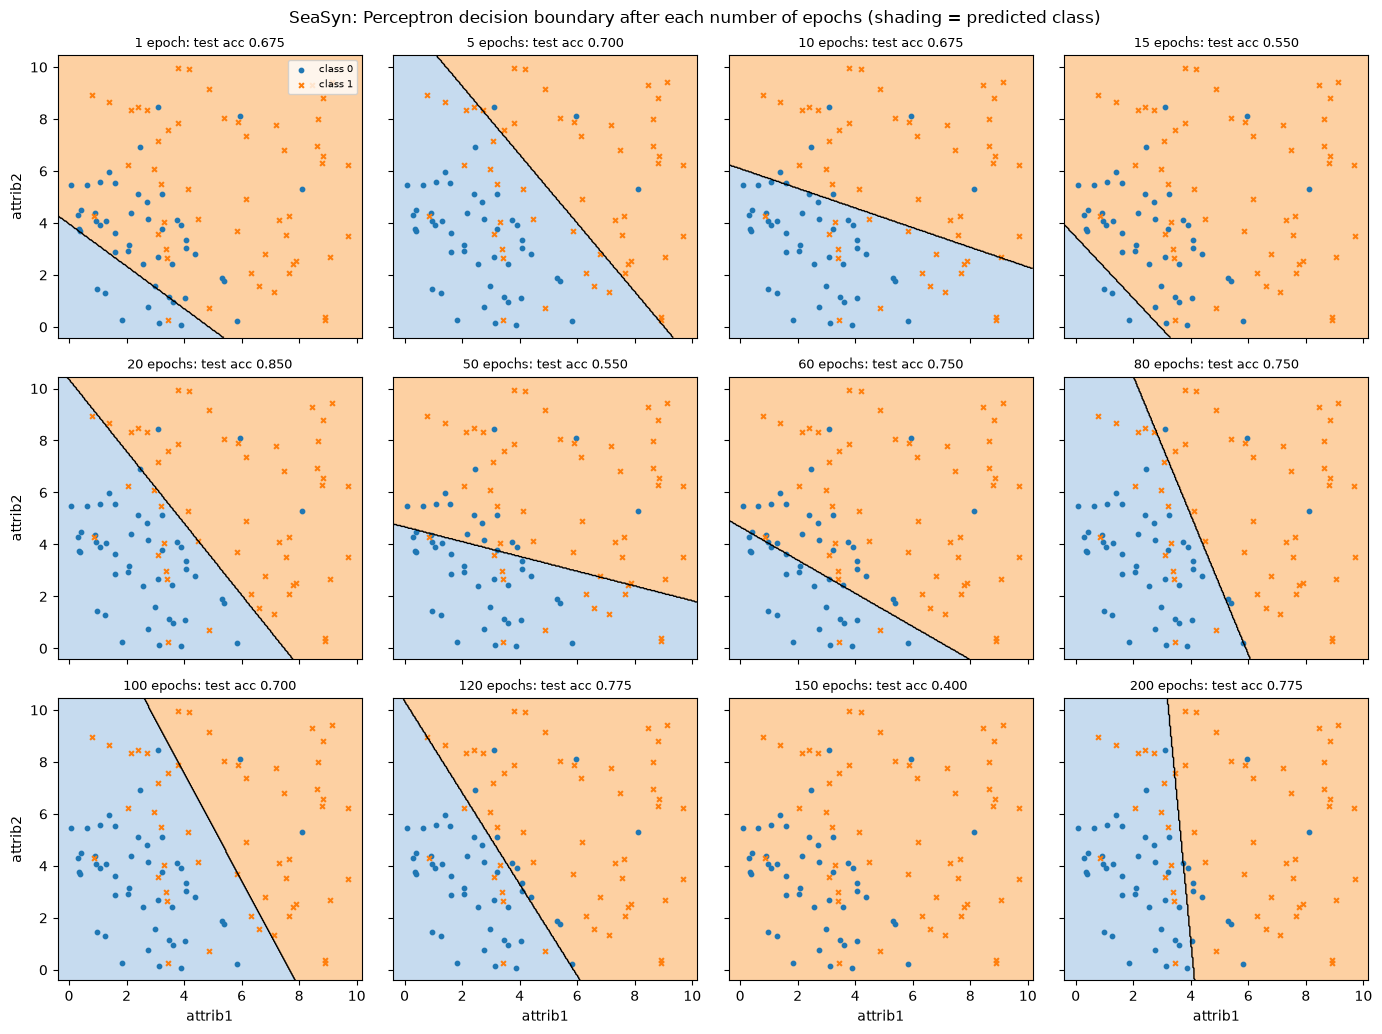

In [4]:
epoch_sweep("SeaSynTrain", "SeaSynTest")

## Task b: RingSyn (not linearly separable)

| Model (epoch)    | Accuracy |
|------------------|----------|
| Perceptron (1)   |    0.743 |
| Perceptron (5)   |    0.697 |
| Perceptron (10)  |    0.757 |


| Perceptron (15)  |    0.727 |


| Perceptron (20)  |    0.640 |


| Perceptron (50)  |    0.747 |


| Perceptron (60)  |    0.790 |


| Perceptron (80)  |    0.730 |


| Perceptron (100) |    0.657 |


| Perceptron (120) |    0.773 |


| Perceptron (150) |    0.727 |


| Perceptron (200) |    0.747 |


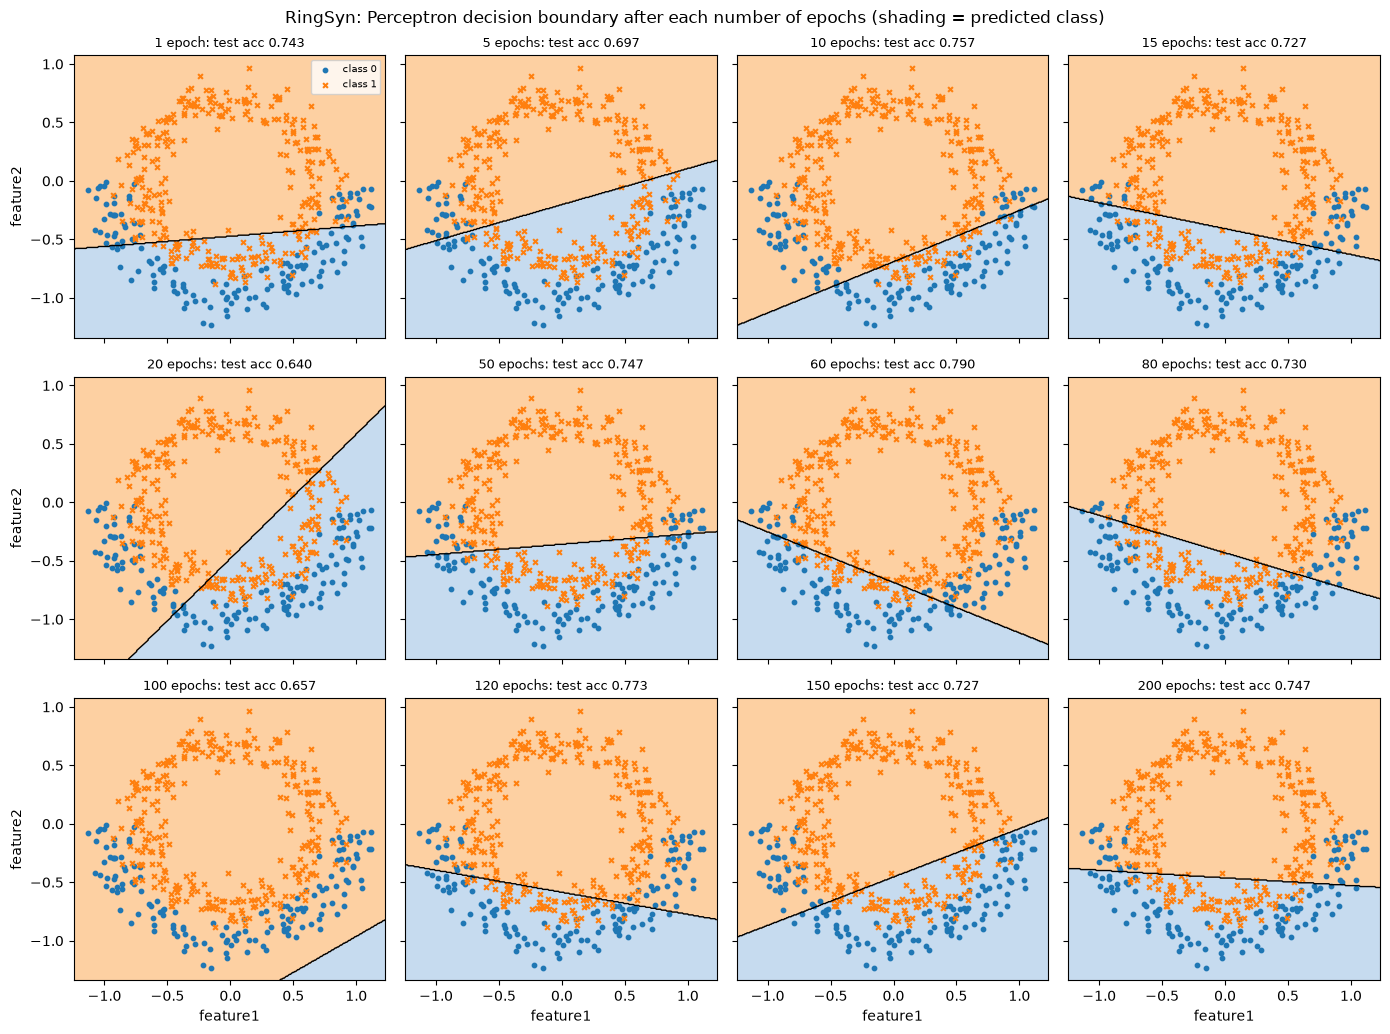

In [5]:
epoch_sweep("RingSynTrain", "RingSynTest")

## Data checks used in the report

- Is the SeaSyn training set linearly separable? (linear-programming feasibility check)
- How do the SeaSyn test rows relate to the training rows?
- What accuracy does always predicting the training set's majority class get on each test set?

In [6]:
from scipy.optimize import linprog


def linearly_separable(X, y):
    """True if some w, b satisfy (2y - 1)(w.x + b) >= 1 for every row, i.e. a line/plane separates the classes."""
    sign = 2 * y - 1
    A_ub = -sign[:, None] * np.c_[X, np.ones(len(X))]
    result = linprog(np.zeros(X.shape[1] + 1), A_ub=A_ub, b_ub=-np.ones(len(X)), bounds=(None, None))
    return result.status == 0  # 0 = a solution exists, 2 = infeasible


(X_train, y_train, _), (X_test, y_test, _) = load("SeaSynTrain"), load("SeaSynTest")
print("SeaSyn train linearly separable:", linearly_separable(X_train, y_train))
n = len(X_test)
print(f"SeaSyn test set is the first {n} train rows:",
      np.array_equal(X_test, X_train[:n]) and np.array_equal(y_test, y_train[:n]))

for name in ["SeaSyn", "RingSyn"]:
    (_, y_train, _), (_, y_test, _) = load(f"{name}Train"), load(f"{name}Test")
    majority = np.bincount(y_train).argmax()
    print(f"{name} majority-class baseline (always predict {majority}): {np.mean(y_test == majority):.3f}")

SeaSyn train linearly separable: False
SeaSyn test set is the first 40 train rows: True
SeaSyn majority-class baseline (always predict 1): 0.525
RingSyn majority-class baseline (always predict 1): 0.657
